# Association learning
Association learning is an unsupervised learning technique used to discover relationships or patterns between variables in a dataset.

# Apriori Algorithm

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [42]:
pd.set_option("display.max_rows",200)

In [43]:
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\groceries - groceries.csv",nrows=1000)
dataset.head(3)

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
dataset.shape

(1000, 33)

In [45]:
dataset.isnull().sum().sum()

np.int64(27750)

In [46]:
dataset.columns

Index(['Item(s)', 'Item 1', 'Item 2', 'Item 3', 'Item 4', 'Item 5', 'Item 6',
       'Item 7', 'Item 8', 'Item 9', 'Item 10', 'Item 11', 'Item 12',
       'Item 13', 'Item 14', 'Item 15', 'Item 16', 'Item 17', 'Item 18',
       'Item 19', 'Item 20', 'Item 21', 'Item 22', 'Item 23', 'Item 24',
       'Item 25', 'Item 26', 'Item 27', 'Item 28', 'Item 29', 'Item 30',
       'Item 31', 'Item 32'],
      dtype='str')

In [47]:
dataset["Item 1"][0]

'citrus fruit'

In [48]:
dataset.shape

(1000, 33)

In [49]:
market = []
for i in range(0,dataset.shape[0]):
    cus = []
    for j in dataset.columns:
        if type(dataset[j][i])==str:
            cus.append(dataset[j][i])
    market.append(cus)

In [50]:
# market list has inside outher list so we need to all item 
l = []
for i in market:
    for j in i:
        l.append(j)

In [51]:
import collections # it is used for counting 

In [52]:
p = collections.Counter(l) 

In [53]:
d = {"Item Name":p.keys(),"values":p.values()}

In [54]:
pd.DataFrame(d).sort_values(by=["values"],ascending=False)

,Item Name,values
7,whole milk,269
17,rolls/buns,222
11,other vegetables,186
31,soda,159
24,bottled water,132
5,yogurt,127
42,root vegetables,110
4,tropical fruit,97
0,citrus fruit,95
35,newspapers,89


In [55]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [57]:
tr = TransactionEncoder()
tr.fit(market)

C:\Users\imrat\AppData\Roaming\Python\Python312\site-packages\sklearn\externals\_numpydoc\docscrape.py:383: UserWarning: potentially wrong underline length... 
Parameters 
------------ in 
Encoder class for transaction data in Python lists
...
  if not self._is_at_section():
C:\Users\imrat\AppData\Roaming\Python\Python312\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Attributes 
------------ in 
Encoder class for transaction data in Python lists
...
  while not self._is_at_section() and not self._doc.eof():
C:\Users\imrat\AppData\Roaming\Python\Python312\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Examples 
------------ in 
Encoder class for transaction data in Python lists
...
  while not self._is_at_section() and not self._doc.eof():


TransactionEncoder()

In [62]:
df = pd.DataFrame(tr.transform(market),columns=tr.columns_)

In [63]:
df

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baking powder,bathroom cleaner,beef,berries,beverages,...,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,True,False,True,True,False
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [64]:
from mlxtend.frequent_patterns import apriori

In [72]:
apriori(df,min_support=0.05,use_colnames=True).sort_values(by=["support"])

,support,itemsets
3,0.050,frozenset({brown bread})
8,0.053,frozenset({domestic eggs})
15,0.053,frozenset({pork})
11,0.056,frozenset({margarine})
27,0.056,"frozenset({yogurt, whole milk})"
10,0.067,frozenset({fruit/vegetable juice})
26,0.068,"frozenset({rolls/buns, whole milk})"
0,0.069,frozenset({beef})
25,0.072,"frozenset({other vegetables, whole milk})"
9,0.073,frozenset({frankfurter})


# FP-Growth
FP-Growth is used to find frequent itemsets in a dataset
(like market basket data) 
without generating candidate sets, which makes it faster than Apriori

Key Concepts

1. Frequent Itemset

Items that appear together frequently in transactions.

2. Support

Frequency of itemset in dataset.

In [74]:
import pandas as pd
import numpy as np

In [78]:
pd.set_option("display.max_rows",200)

In [80]:
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\groceries - groceries.csv")
dataset.head(3)

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
dataset.shape

(9835, 33)

In [82]:
market = []
for i in range(0,dataset.shape[0]):
    cus = []
    for j in dataset.columns:
        if type(dataset[j][i]) == str:
            cus.append(dataset[j][i])
    market.append(cus)

In [92]:
l = []
for i in market:
    for j in i:
        l.append(j)

In [93]:
import collections

In [94]:
collections.Counter(l)

Counter({'whole milk': 2513,
         'other vegetables': 1903,
         'rolls/buns': 1809,
         'soda': 1715,
         'yogurt': 1372,
         'bottled water': 1087,
         'root vegetables': 1072,
         'tropical fruit': 1032,
         'shopping bags': 969,
         'sausage': 924,
         'pastry': 875,
         'citrus fruit': 814,
         'bottled beer': 792,
         'newspapers': 785,
         'canned beer': 764,
         'pip fruit': 744,
         'fruit/vegetable juice': 711,
         'whipped/sour cream': 705,
         'brown bread': 638,
         'domestic eggs': 624,
         'frankfurter': 580,
         'margarine': 576,
         'coffee': 571,
         'pork': 567,
         'butter': 545,
         'curd': 524,
         'beef': 516,
         'napkins': 515,
         'chocolate': 488,
         'frozen vegetables': 473,
         'chicken': 422,
         'white bread': 414,
         'cream cheese': 390,
         'waffles': 378,
         'salty snack': 372,
      

In [95]:
d= {"Item name":p.keys(),"values":p.values()}

In [96]:
pd.DataFrame(d).sort_values(by=["values"],ascending=False)

,Item name,values
7,whole milk,269
17,rolls/buns,222
11,other vegetables,186
31,soda,159
24,bottled water,132
5,yogurt,127
42,root vegetables,110
4,tropical fruit,97
0,citrus fruit,95
35,newspapers,89


In [100]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [102]:
tr = TransactionEncoder()
tr.fit(market)

TransactionEncoder()

In [103]:
pd.DataFrame(tr.transform(market),columns=tr.columns_)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9833,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [108]:
from mlxtend.frequent_patterns import fpgrowth

In [112]:
fpgrowth(df,min_support=0.05,use_colnames=True,max_len=3).sort_values(by=["support"])

,support,itemsets
21,0.050,frozenset({brown bread})
23,0.053,frozenset({pork})
24,0.053,frozenset({domestic eggs})
1,0.056,frozenset({margarine})
25,0.056,"frozenset({yogurt, whole milk})"
15,0.067,frozenset({fruit/vegetable juice})
27,0.068,"frozenset({rolls/buns, whole milk})"
11,0.069,frozenset({beef})
26,0.072,"frozenset({other vegetables, whole milk})"
13,0.073,frozenset({frankfurter})


# Ensemble learning

# max voting for classification data

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

In [133]:
x,y = make_moons(n_samples=1000,noise=0.2)

In [134]:
df = {"x1":x[:,0],"x2":x[:,1],"y":y}

In [135]:
dataset = pd.DataFrame(df)

In [136]:
dataset

,x1,x2,y
0,-0.119837,1.240553,0
1,-0.814366,0.706126,0
2,-0.688515,0.721592,0
3,-0.885831,-0.012439,0
4,-0.810460,0.786114,0
...,...,...,...
995,-0.071922,0.059894,1
996,0.418961,0.432877,0
997,2.053581,0.026012,1
998,0.140393,1.225133,0


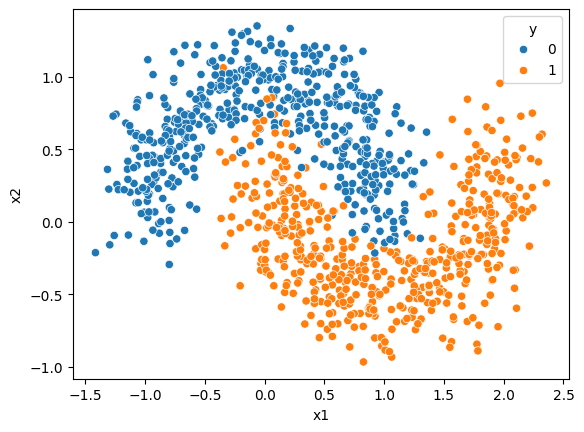

In [137]:
sns.scatterplot(x="x1",y="x2",data=dataset,hue="y")
plt.show()

In [138]:
x_a = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [139]:
from sklearn.model_selection import train_test_split

In [140]:
x_train,x_test,y_train,y_test = train_test_split(x_a,y_a,test_size=0.2,random_state=42)


In [143]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [146]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
dt.score(x_test,y_test)*100,dt.score(x_train,y_train)*100

(96.0, 100.0)

In [147]:
sv = SVC()
sv.fit(x_train,y_train)
sv.score(x_test,y_test)*100,sv.score(x_train,y_train)*100

(97.5, 96.375)

In [149]:
nb = GaussianNB()
nb.fit(x_train,y_train)
nb.score(x_test,y_test)*100,nb.score(x_train,y_train)*100

(85.5, 86.375)

In [150]:
from sklearn.ensemble import VotingClassifier

In [156]:
li = [("dt",DecisionTreeClassifier()),("sv",SVC()),("nb",GaussianNB())]

In [162]:
vc = VotingClassifier(li,weights=[5,4,7])
vc.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt', ...), ('sv', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[5, 4, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [161]:
vc.score(x_train,y_train)*100,vc.score(x_test,y_test)*100

(97.0, 97.5)

In [164]:
prd = {"dt":dt.predict(x_test),"sv":sv.predict(x_test),"nb":nb.predict(x_test),"vc":vc.predict(x_test)}

In [165]:
pd.DataFrame(prd)

,dt,sv,nb,vc
0,1,1,1,1
1,0,0,0,0
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,1,1,1,1


# max_voting for regression data

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
dataset = pd.read_csv(r"C:\Users\imrat\OneDrive\Desktop\data_science_all_uses_items\Data_set\placement.csv")
dataset.head(3)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25


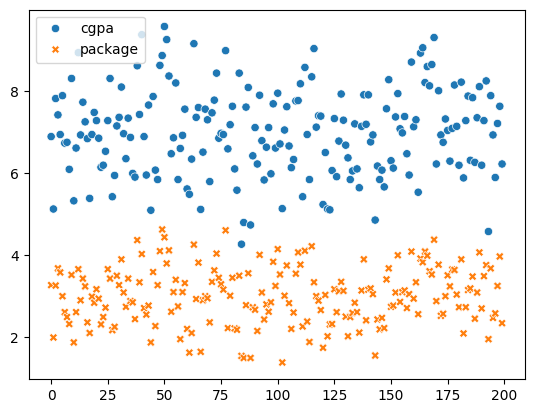

In [171]:
sns.scatterplot(data=dataset)
plt.show()

In [172]:
x = dataset.iloc[:,:1]
y = dataset["package"]

In [173]:
from sklearn.model_selection import train_test_split

In [174]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [175]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [178]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100,lr.score(x_train,y_train)*100

(77.30984312051673, 77.58339025733345)

In [179]:
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)
dt.score(x_test,y_test)*100,dt.score(x_train,y_train)*100

(52.19733481708333, 95.1559200955432)

In [180]:
sv = SVR()
sv.fit(x_train,y_train)
sv.score(x_test,y_test)*100,sv.score(x_train,y_train)*100

(75.94945442913415, 78.16909319813372)

In [182]:
from sklearn.ensemble import VotingRegressor

In [184]:
li = [("lr",LinearRegression()),("dt",DecisionTreeRegressor()),("sv",SVR())]

In [189]:
vc = VotingRegressor(li,weights=[15,20,30])
vc.fit(x_train,y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.","[15, 20, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


In [190]:
vc.score(x_test,y_test)*100,vc.score(x_train,y_train)*100

(75.29609261804147, 87.00936776069136)

In [193]:
df = {"lr":lr.predict(x_test),"dt":dt.predict(x_test),"sv":sv.predict(x_test),"vc":vc.predict(x_test)}

In [195]:
pd.DataFrame(df).head(3)

,lr,dt,sv,vc
0,2.780313,2.9200,2.745462,2.807209
1,3.136352,3.2525,3.111375,3.160562
2,3.199521,2.9200,3.186923,3.107700


In [196]:
(2.780313+2.9200+2.745462)/3

2.815258333333333